In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
training_dataset_path = "./data/training_data/training_dataset.parquet"

df = pd.read_parquet(training_dataset_path)

Classification Report:
              precision    recall  f1-score   support

         0.0      0.643     0.409     0.500        22
         1.0      0.912     0.964     0.938       140

    accuracy                          0.889       162
   macro avg      0.778     0.687     0.719       162
weighted avg      0.876     0.889     0.878       162



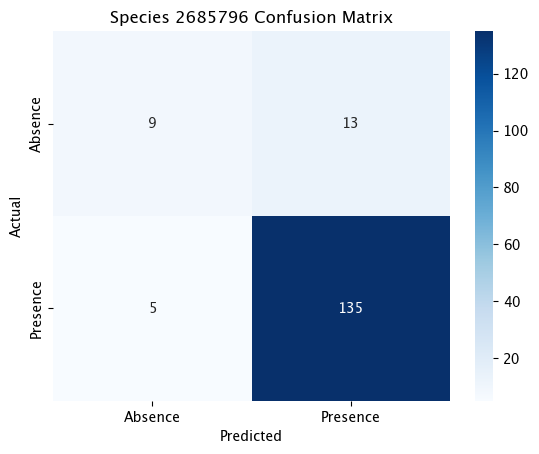

In [4]:


# --- Load your dataset (if not already loaded) ---
# df = pd.read_csv("your_data.csv")

# --- Features and target ---
band_cols = [col for col in df.columns if col.startswith("band_")]
target_col = "2685796"  # your species column (presence/absence)

df_clean = df.dropna(subset=[target_col])
X = df_clean[band_cols]
y = df_clean[target_col]

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# --- Model training ---
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)

# --- Predictions ---
y_pred = clf.predict(X_test)

# --- Metrics ---
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Absence", "Presence"],
            yticklabels=["Absence", "Presence"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Species {target_col} Confusion Matrix")
plt.show()


In [5]:
# --- Drop missing values from target ---import pandas as pd
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier  # Uncomment if working

# --- Define your features and target ---
target_col = "2685796"
X = df[[col for col in df.columns if col.startswith("band_")]].copy()
y = df[target_col].fillna(0).astype(int)  # ensure no NaNs

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# --- Define models ---
models = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "SVM (RBF Kernel)": SVC(class_weight="balanced", probability=True),
    "HistGradientBoosting": HistGradientBoostingClassifier(),
    "XGBoost": XGBClassifier(scale_pos_weight=(y == 0).sum() / (y == 1).sum(), use_label_encoder=False, eval_metric='logloss', verbosity=0),
    "LightGBM": LGBMClassifier(class_weight="balanced", random_state=42),
}

# --- Evaluate each model ---
results = []
conf_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

# --- Display results ---
results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False).reset_index(drop=True)


/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 419, number of negative: 750
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001742 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 55722
[LightGBM] [Info] Number of data points in the train set: 1169, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [6]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.974359,0.971014,0.957143,0.964029
1,Logistic Regression,0.966667,0.950355,0.957143,0.953737
2,HistGradientBoosting,0.966667,0.977444,0.928571,0.952381
3,LightGBM,0.964103,0.963235,0.935714,0.949275
4,Random Forest,0.964103,0.977273,0.921429,0.948529
5,SVM (RBF Kernel),0.874359,0.797386,0.871429,0.832765


In [7]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# --- Prepare data ---
target_col = "2685796"
df_clean = df.dropna(subset=[target_col])
X = df_clean[[col for col in df_clean.columns if col.startswith("band_")]]
y = df_clean[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# --- Define models ---
models = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "SVM (RBF Kernel)": SVC(class_weight="balanced", probability=True),
    "HistGradientBoosting": HistGradientBoostingClassifier(),
    "XGBoost": XGBClassifier(
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42
    ),
}

# --- Loop through models and print classification reports ---
for name, model in models.items():
    print(f"\n🔍 {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))



🔍 Random Forest
Classification Report:
              precision    recall  f1-score   support

           0      0.643     0.409     0.500        22
           1      0.912     0.964     0.938       140

    accuracy                          0.889       162
   macro avg      0.778     0.687     0.719       162
weighted avg      0.876     0.889     0.878       162


🔍 Logistic Regression
Classification Report:
              precision    recall  f1-score   support

           0      0.667     0.727     0.696        22
           1      0.957     0.943     0.950       140

    accuracy                          0.914       162
   macro avg      0.812     0.835     0.823       162
weighted avg      0.917     0.914     0.915       162


🔍 SVM (RBF Kernel)


/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Report:
              precision    recall  f1-score   support

           0      0.500     0.727     0.593        22
           1      0.954     0.886     0.919       140

    accuracy                          0.864       162
   macro avg      0.727     0.806     0.756       162
weighted avg      0.892     0.864     0.874       162


🔍 HistGradientBoosting
Classification Report:
              precision    recall  f1-score   support

           0      0.750     0.545     0.632        22
           1      0.932     0.971     0.951       140

    accuracy                          0.914       162
   macro avg      0.841     0.758     0.791       162
weighted avg      0.907     0.914     0.908       162


🔍 XGBoost


/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:41:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
              precision    recall  f1-score   support

           0      0.625     0.682     0.652        22
           1      0.949     0.936     0.942       140

    accuracy                          0.901       162
   macro avg      0.787     0.809     0.797       162
weighted avg      0.905     0.901     0.903       162



# All species

In [8]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import pandas as pd

# --- Output file ---
output_path = "species_model_reports.txt"

# --- Get list of spectral band columns ---
band_cols = [col for col in df.columns if col.startswith("band_")]

# --- Get list of species target columns (assumes GBIF taxon IDs) ---
species_cols = [col for col in df.columns if col not in band_cols
                and col not in ['plot_id', 'scene_id', 'pixel_id', 'row', 'col', 'centroid']
                and str(col).isdigit()]

# --- Define models ---
def get_models(y_train):
    return {
        "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
        "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
        "SVM (RBF Kernel)": SVC(class_weight="balanced", probability=True),
        "HistGradientBoosting": HistGradientBoostingClassifier(),
        "XGBoost": XGBClassifier(
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=42
        ),
    }

# --- Run all models and capture results ---
results = []

for species_col in species_cols:
    df_clean = df.dropna(subset=[species_col])
    if df_clean[species_col].nunique() < 2:
        continue  # Skip species with only 1 class
    
    X = df_clean[band_cols]
    y = df_clean[species_col].astype(int)

    if len(y) < 40:
        continue

    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, stratify=y, test_size=0.25, random_state=42
        )
    except ValueError:
        continue  # Skip if stratified split fails

    header = f"\n\n==========================\n📌 Species: {species_col} ({(y==1).sum()} positive samples)\n=========================="
    results.append(header)

    for name, model in get_models(y_train).items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, digits=3)
        entry = f"\n🔍 {name}\nClassification Report:\n{report}"
        results.append(entry)

# --- Write to file ---
with open(output_path, "w") as f:
    f.write("\n".join(results))


/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:41:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: Conve

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

def plot_feature_importance(df, species_col, model_name="Random Forest", top_n=30):
    # --- Prepare data ---
    df_clean = df.dropna(subset=[species_col])
    X = df_clean[[col for col in df_clean.columns if col.startswith("band_")]]
    y = df_clean[species_col].astype(int)

    # --- Train model ---
    model = RandomForestClassifier(class_weight="balanced", random_state=42)
    model.fit(X, y)

    # --- Get importances ---
    importances = model.feature_importances_
    band_names = X.columns
    importance_df = pd.DataFrame({
        "band": band_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    # --- Plot ---
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(top_n), x="band", y="importance", palette="viridis")
    plt.xticks(rotation=90)
    plt.title(f"Top {top_n} Most Important Bands for Species {species_col} ({model_name})")
    plt.tight_layout()
    plt.show()

    return importance_df


/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/4052966340.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(top_n), x="band", y="importance", palette="viridis")


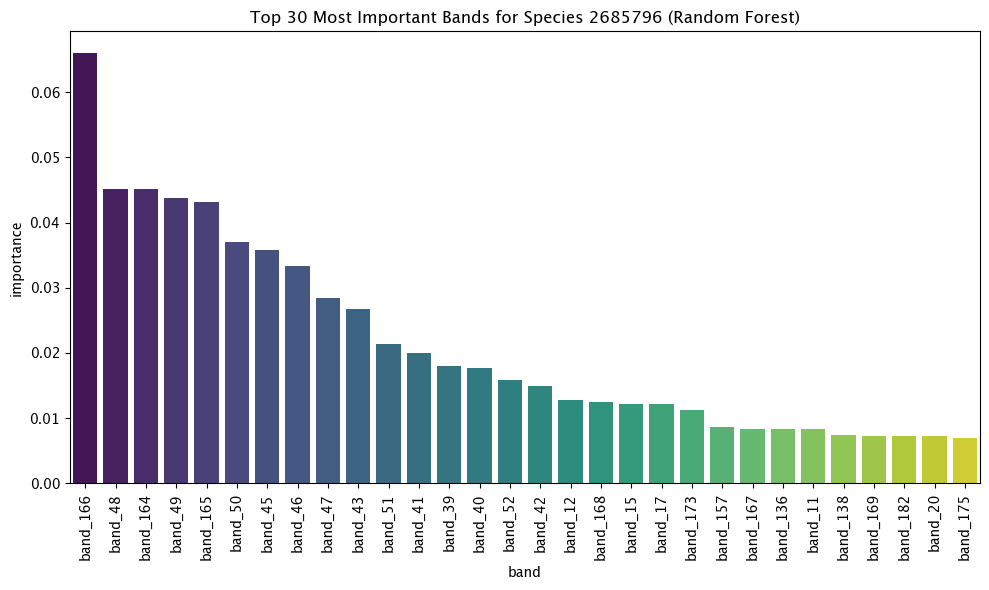

In [10]:
imp_df = plot_feature_importance(df, species_col="2685796", model_name="Random Forest")


In [17]:
import numpy as np

# Approximate EnMAP wavelength centers, interpolated
wavelengths = np.linspace(420, 2450, 224)  # You can refine this if you have exact centers


In [18]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

def plot_spectral_feature_importance(df, species_col, wavelengths, model_name="Random Forest"):
    # --- Prepare data ---
    df_clean = df.dropna(subset=[species_col])
    X = df_clean[[col for col in df_clean.columns if col.startswith("band_")]]
    y = df_clean[species_col].astype(int)

    # --- Train model ---
    model = RandomForestClassifier(class_weight="balanced", random_state=42)
    model.fit(X, y)

    # --- Extract importances ---
    importances = model.feature_importances_
    
    # --- Plot ---
    plt.figure(figsize=(12, 4))
    plt.plot(wavelengths, importances, marker='o', lw=1)
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Feature Importance")
    plt.title(f"Spectral Feature Importance for Species {species_col} ({model_name})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


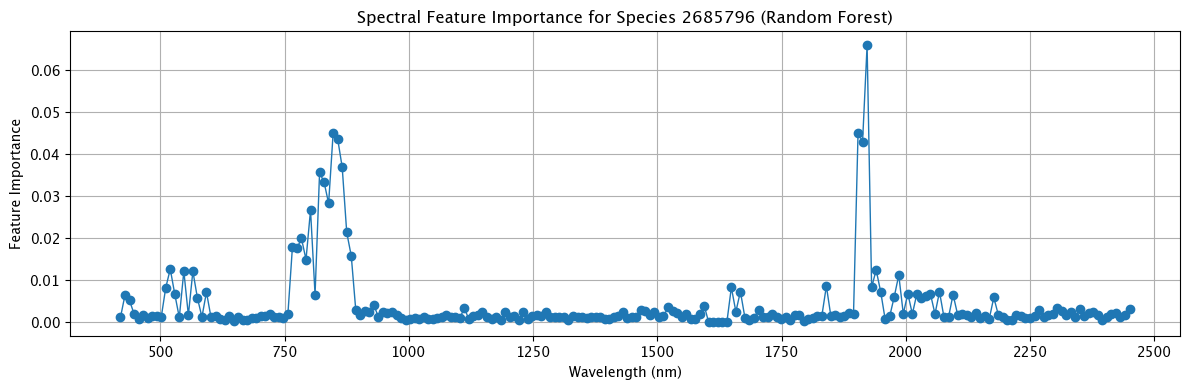

In [19]:
plot_spectral_feature_importance(df, species_col="2685796", wavelengths=wavelengths)


In [35]:
import numpy as np
import matplotlib.pyplot as plt

def plot_avg_spectra_with_importance(mean_0, mean_1, importances, wavelengths, masked_bands=np.arange(131, 136)):
    """
    Plot average spectrum for classes 0 and 1 with feature importance and masked band shading.

    Parameters:
        mean_0 (np.ndarray): Mean spectrum for class 0 (absent)
        mean_1 (np.ndarray): Mean spectrum for class 1 (present)
        importances (np.ndarray): Feature importances from model (length = num bands)
        wavelengths (np.ndarray): Wavelengths corresponding to EnMAP bands
        masked_bands (array-like): List of band indices to mask (default: 131–135)
    """
    # --- Mask out specified bands ---
    band_indices = np.arange(len(wavelengths))
    mask = np.isin(band_indices, masked_bands)
    
    mean_0_masked = np.ma.masked_where(mask, mean_0)
    mean_1_masked = np.ma.masked_where(mask, mean_1)

    # --- Normalize feature importances for red shading ---
    norm_importance = (importances - np.min(importances)) / (np.max(importances) - np.min(importances))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 6))

    # Red shading by feature importance
    for wl, imp in zip(wavelengths, norm_importance):
        ax.axvspan(wl - 4, wl + 4, color=(1, 0, 0, imp * 0.2))  # red with alpha scaling

    # Gray box for masked bands
    min_mask = wavelengths[masked_bands[0]]
    max_mask = wavelengths[masked_bands[-1]]
    ax.axvspan(min_mask - 5, max_mask + 5, color="gray", alpha=0.3, label="Masked region")

    # Plot masked spectra lines
    ax.plot(wavelengths, mean_0_masked, label="Absent (0)", color="blue", lw=2)
    ax.plot(wavelengths, mean_1_masked, label="Present (1)", color="green", lw=2)

    # Final formatting
    ax.set_title("Average Spectra with Feature Importance and Masked Bands")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Reflectance")
    ax.legend()
    plt.tight_layout()
    plt.show()


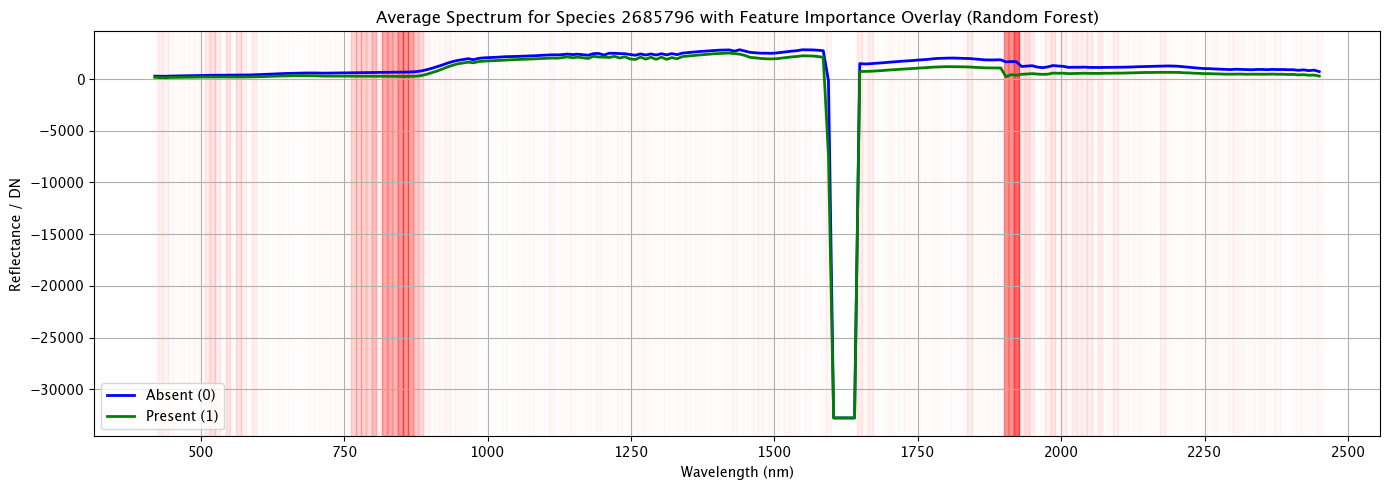

In [21]:
wavelengths = np.linspace(420, 2450, 224)  # Or use your actual EnMAP band centers
plot_avg_spectra_with_importance(df, species_col="2685796", wavelengths=wavelengths)


In [53]:
import pandas as pd

# Load the spectral band file
band_df = pd.read_excel("./data/enmap_downloads/EnMAP_Spectral_Bands.xlsx")

# Create a lookup array of center wavelengths
center_wavelengths = band_df["CW (nm)"].values
fwhm = band_df["FWHM (nm)"].values


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

def plot_spectrum_with_importance(df, species_code, masked_bands=np.arange(130, 136)):
    """
    Plot the average reflectance spectrum for a species presence/absence,
    colored by feature importance from a Random Forest classifier.

    Parameters:
        df (pd.DataFrame): DataFrame with band_ features and species columns (as 0/1)
        species_code (str or int): Column name of species presence/absence (e.g., "2878124")
        masked_bands (array-like): Band indices to mask (default is 131–135)
    """
    # --- Extract features and target ---
    band_cols = [c for c in df.columns if c.startswith("band_")]
    target_col = str(species_code)
    df_clean = df.dropna(subset=band_cols + [target_col])
    
    X = df_clean[band_cols].values
    y = df_clean[target_col].astype(int).values

    # --- Fit Random Forest ---
    clf = RandomForestClassifier(class_weight="balanced", random_state=42)
    clf.fit(X, y)
    importances = clf.feature_importances_

    # --- Compute average spectra ---
    mean_0 = X[y == 0].mean(axis=0)
    mean_1 = X[y == 1].mean(axis=0)

    # --- Convert band names to wavelengths ---
    band_indices = np.array([int(c.split("_")[1]) for c in band_cols])
    wavelengths = band_indices * 10  # assuming EnMAP bands are in 10 nm steps
    

    # --- Mask out bad bands ---
    mask = np.isin(band_indices, masked_bands)
    mean_0_masked = np.ma.masked_where(mask, mean_0)
    mean_1_masked = np.ma.masked_where(mask, mean_1)

    # --- Normalize importance ---
    norm_imp = (importances - np.min(importances)) / (np.max(importances) - np.min(importances))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 6))

    # Red shading by feature importance
    for wl, imp in zip(wavelengths, norm_imp):
        ax.axvspan(wl - 4, wl + 4, color=(1, 0, 0, imp * 0.2))

    # Masked band region
    min_mask = wavelengths[masked_bands[0]]
    max_mask = wavelengths[masked_bands[-1]]
    ax.axvspan(min_mask - 5, max_mask + 5, color="gray", alpha=0.3, label="Masked region")

    # Spectra
    ax.plot(wavelengths, mean_0_masked, label="Absent (0)", color="blue", lw=2)
    ax.plot(wavelengths, mean_1_masked, label="Present (1)", color="green", lw=2)

    ax.set_title(f"Spectrum with Feature Importance — Species {species_code}")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Reflectance")
    ax.legend()
    plt.tight_layout()
    plt.show()


KeyError: 0

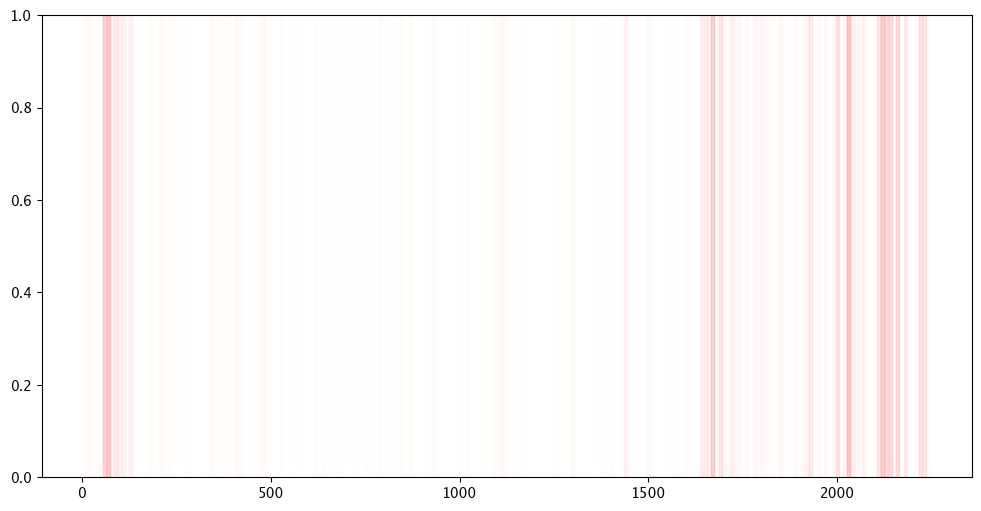

In [63]:

# Run for a specific species code
plot_spectrum_with_importance(df, "2878124", band_df)


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

def plot_spectrum_derivative_with_importance(df, species_code, masked_bands=np.arange(120, 140)):
    """
    Plot the first derivative of the average reflectance spectra for class 0 and 1,
    with Random Forest feature importance shaded and masked bands shown.

    Parameters:
        df (pd.DataFrame): DataFrame with band_ features and species columns (as 0/1)
        species_code (str or int): Column name of species presence/absence (e.g., "2878124")
        masked_bands (array-like): Band indices to mask (default is 131–135)
    """
    # --- Extract features and target ---
    band_cols = [c for c in df.columns if c.startswith("band_")]
    target_col = str(species_code)
    df_clean = df.dropna(subset=band_cols + [target_col])
    
    X = df_clean[band_cols].values
    y = df_clean[target_col].astype(int).values

    # --- Fit Random Forest ---
    clf = RandomForestClassifier(class_weight="balanced", random_state=42)
    clf.fit(X, y)
    importances = clf.feature_importances_

    # --- Compute average spectra ---
    mean_0 = X[y == 0].mean(axis=0)
    mean_1 = X[y == 1].mean(axis=0)

    # --- Convert band names to wavelengths ---
    band_indices = np.array([int(c.split("_")[1]) for c in band_cols])
    wavelengths = band_indices * 10  # assuming 10nm steps

    # --- Compute first derivative ---
    d_mean_0 = np.gradient(mean_0, wavelengths)
    d_mean_1 = np.gradient(mean_1, wavelengths)

    # --- Masking ---
    mask = np.isin(band_indices, masked_bands)
    d_mean_0_masked = np.ma.masked_where(mask, d_mean_0)
    d_mean_1_masked = np.ma.masked_where(mask, d_mean_1)

    # --- Normalize importance ---
    norm_imp = (importances - np.min(importances)) / (np.max(importances) - np.min(importances))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 6))

    # Red shading by feature importance
    for wl, imp in zip(wavelengths, norm_imp):
        ax.axvspan(wl - 4, wl + 4, color=(1, 0, 0, imp * 0.2))

    # Masked region
    min_mask = wavelengths[masked_bands[0]]
    max_mask = wavelengths[masked_bands[-1]]
    ax.axvspan(min_mask - 5, max_mask + 5, color="gray", alpha=0.3, label="Masked region")

    # Derivative lines
    ax.plot(wavelengths, d_mean_0_masked, label="Absent (0)", color="blue", lw=2)
    ax.plot(wavelengths, d_mean_1_masked, label="Present (1)", color="green", lw=2)

    ax.set_title(f"1st Derivative Spectrum with Feature Importance — Species {species_code}")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Reflectance Derivative")
    ax.legend()
    plt.tight_layout()
    plt.show()


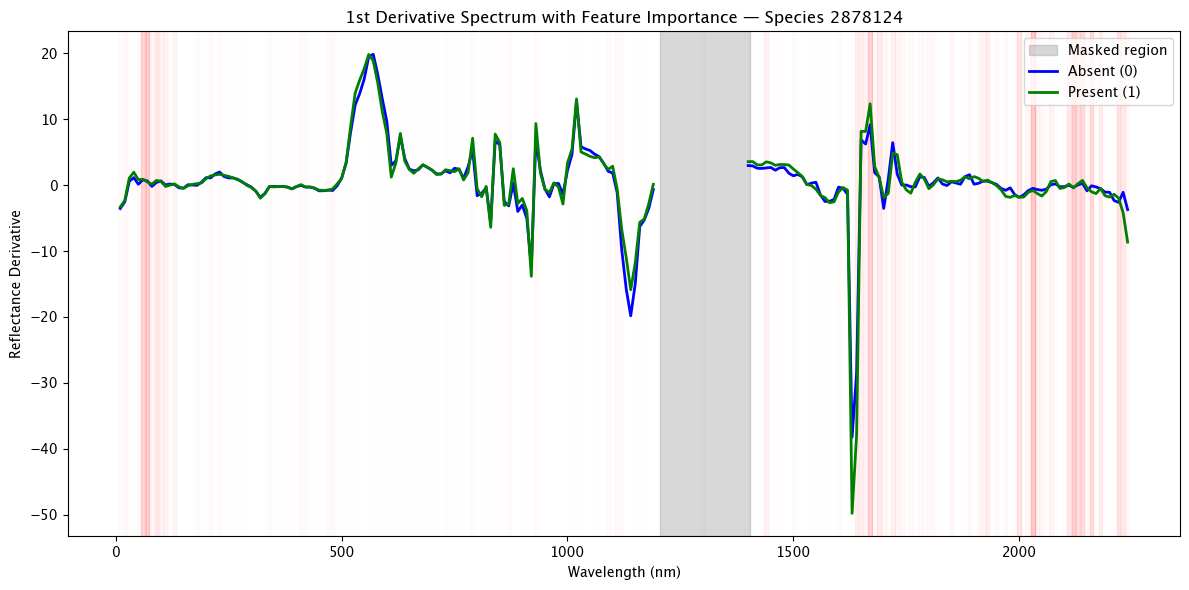

In [49]:
plot_spectrum_derivative_with_importance(df, "2878124")


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from sklearn.ensemble import RandomForestClassifier

def plot_average_spectrum_with_importance(
    df: pd.DataFrame,
    species_code: str,
    band_df: pd.DataFrame,
    title_prefix: str = "Average Spectrum by Class",
    derivative_order: int = 0,
):
    """
    Plot average spectrum (or its n-th derivative) for classes 0/1 with
    feature importance shown as a red overlay (deeper red = more important).

    Requirements:
      - df has band_* columns (band_1..band_N) and a binary target column == species_code.
      - band_df provides wavelength info:
          * Prefer "CW (nm)" or "Middle WL".
          * Otherwise compute midpoint of "Start WL" and "End WL".

    Behaviors:
      - Any band_* column that contains -32768 in df is masked (gray vspan, no line connection).
      - Y-limits are computed ignoring masked values.
      - derivative_order can be 0 (raw), 1 (first), 2 (second), ...

    """
    # --- Gather X/y ---
    band_cols = [c for c in df.columns if c.startswith("band_")]
    if not band_cols:
        raise ValueError("No band_* columns found in df.")

    X = df[band_cols].to_numpy(dtype=float)
    if species_code not in df.columns:
        raise ValueError(f"Target column '{species_code}' not found in df.")
    y = df[species_code].to_numpy(dtype=float)

    # Drop rows with NaN targets
    keep_rows = ~np.isnan(y)
    X, y = X[keep_rows], y[keep_rows].astype(int)

    # --- Detect bad bands across rows: any -32768 -> mask that band ---
    bad_band = np.any(X == -32768, axis=0)  # shape (N_bands,)

    # --- Train a quick RF to get feature importances (same importances used for both curves) ---
    rf = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1,
    )
    rf.fit(X, y)
    importances = rf.feature_importances_  # shape (N_bands,)

    # --- Build wavelength vector from band_df ---
    n_bands = X.shape[1]

    def pick_cw(df_meta: pd.DataFrame) -> np.ndarray:
        cols = {c.lower(): c for c in df_meta.columns}
        if "cw (nm)" in cols:
            return df_meta[cols["cw (nm)"]].to_numpy()
        if "middle wl" in cols:
            return df_meta[cols["middle wl"]].to_numpy()
        # Try Start/End
        # Be flexible about label spelling/case
        start_col = None
        end_col = None
        for key, orig in cols.items():
            if "start" in key and "wl" in key:
                start_col = orig
            if "end" in key and "wl" in key:
                end_col = orig
        if start_col is not None and end_col is not None:
            return (df_meta[start_col].to_numpy() + df_meta[end_col].to_numpy()) / 2.0
        raise ValueError("band_df needs 'CW (nm)', 'Middle WL', or Start/End WL columns.")

    cw = pick_cw(band_df)
    if len(cw) < n_bands:
        raise ValueError(f"band_df has {len(cw)} bands but df has {n_bands} band_* columns.")
    cw = cw[:n_bands]

    # --- Sort by wavelength for clean plotting ---
    order = np.argsort(cw)
    wl = cw[order]
    imp = importances[order]
    bad_sorted = bad_band[order]

    # Average spectra by class
    mean0 = np.nanmean(X[y == 0], axis=0)[order]
    mean1 = np.nanmean(X[y == 1], axis=0)[order]

    # --- Apply masking to the means ---
    m0 = np.ma.masked_where(bad_sorted, mean0)
    m1 = np.ma.masked_where(bad_sorted, mean1)

    # --- Optionally take n-th derivative (on masked arrays, preserving gaps) ---
    def masked_derivative(vals_ma: np.ma.MaskedArray, x: np.ndarray, n: int) -> np.ma.MaskedArray:
        if n <= 0:
            return vals_ma
        out = vals_ma.copy()
        for _ in range(n):
            # fill masked with nan, take gradient in wavelength, re-mask nans and original masked
            arr = out.filled(np.nan)
            darr = np.gradient(arr, x)
            out = np.ma.masked_invalid(darr)
            # also keep original masked positions masked
            out.mask = np.logical_or(out.mask, vals_ma.mask)
        return out

    m0 = masked_derivative(m0, wl, derivative_order)
    m1 = masked_derivative(m1, wl, derivative_order)

    # --- Normalize importances to control red alpha strength ---
    imp_norm = np.zeros_like(imp)
    if np.nanmax(imp) > 0:
        imp_norm = imp / np.nanmax(imp)

    # Make red alpha a bit punchier but bounded
    # map [0,1] -> [0.05, 0.9] with slight gamma for contrast
    gamma = 0.7
    red_alpha = 0.05 + 0.85 * (imp_norm ** gamma)

    # --- Helper: build red LineCollection segments per contiguous unmasked run ---
    def red_overlay(ax, x, y_ma, alpha_per_band):
        # y_ma is masked array; do not draw segments that touch masked points
        y = y_ma
        valid = ~y.mask
        idx = np.where(valid)[0]
        if idx.size < 2:
            return
        # Split into contiguous runs
        splits = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
        for run in splits:
            if len(run) < 2:
                continue
            seg_x = x[run]
            seg_y = y[run].filled(np.nan)
            seg_a = alpha_per_band[run]
            # Build segment list: [( (x0,y0),(x1,y1) ), ...]
            points = np.column_stack([seg_x, seg_y])
            segments = np.stack([points[:-1], points[1:]], axis=1)
            # Segment alpha = mean of endpoints
            seg_alpha = 0.5 * (seg_a[:-1] + seg_a[1:])
            # Create a LineCollection with RGBA colors per-segment
            colors = np.zeros((len(segments), 4))
            colors[:, 0] = 1.0  # red
            colors[:, 3] = seg_alpha  # alpha
            lc = LineCollection(segments, colors=colors, linewidths=4, zorder=4)
            ax.add_collection(lc)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(11.5, 5.5))

    # Gray spans for masked bands (contiguous)
    masked_idx = np.where(bad_sorted)[0]
    if masked_idx.size > 0:
        runs = np.split(masked_idx, np.where(np.diff(masked_idx) != 1)[0] + 1)
        for r in runs:
            ax.axvspan(wl[r[0]], wl[r[-1]], color="gray", alpha=0.15, zorder=0)

    # Base spectra (thin) so the red overlay can “redden” where important
    lbl0 = "class 0"
    lbl1 = "class 1"
    ax.plot(wl, m0, label=lbl0, linewidth=1.8, zorder=2)
    ax.plot(wl, m1, label=lbl1, linewidth=1.8, zorder=3)

    # Red importance overlay (thicker, variable alpha)
    red_overlay(ax, wl, m0, red_alpha)
    red_overlay(ax, wl, m1, red_alpha)

    # Y-lims ignoring masked values (and ignoring NaNs)
    vals = np.concatenate([m0.compressed(), m1.compressed()])
    if vals.size:
        vmin, vmax = np.nanmin(vals), np.nanmax(vals)
        pad = 0.02 * (vmax - vmin if vmax > vmin else 1.0)
        ax.set_ylim(vmin - pad, vmax + pad)

    # Labels / title
    ylab = "Reflectance" if derivative_order == 0 else f"{derivative_order}ᵗʰ derivative"
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(ylab)
    ax.set_title(f"{title_prefix} — species {species_code} — derivative order: {derivative_order}")
    ax.grid(True, alpha=0.25)

    # Legend (with a proxy for importance)
    from matplotlib.lines import Line2D
    proxy_red = Line2D([0], [0], color="red", lw=6, alpha=0.7)
    leg = ax.legend(handles=[
        Line2D([0], [0], color=ax.lines[0].get_color(), lw=2, label=lbl0),
        Line2D([0], [0], color=ax.lines[1].get_color(), lw=2, label=lbl1),
        proxy_red
    ], labels=[lbl0, lbl1, "deeper red = higher importance"], loc="best")
    plt.tight_layout()
    plt.show()


In [97]:
import pandas as pd
import numpy as np
from io import StringIO

def _normalize_band_meta_columns(df: pd.DataFrame) -> pd.DataFrame:
    # lower + strip
    df = df.rename(columns={c: str(c).strip().lower() for c in df.columns})
    band_col   = next((c for c in df.columns if c.startswith("nr")), None)
    start_col  = next((c for c in df.columns if "start" in c and "wl" in c), None)
    middle_col = next((c for c in df.columns if ("middle" in c or "center" in c or "centre" in c) and "wl" in c), None)
    end_col    = next((c for c in df.columns if "end" in c and "wl" in c), None)
    sprg_col   = next((c for c in df.columns if c.startswith("sp.rg")), None)

    if not (band_col and middle_col and ((start_col and end_col) or sprg_col)):
        raise ValueError(f"Band meta columns not found. Got columns: {list(df.columns)}")

    out = pd.DataFrame()
    out["BAND #"]  = pd.to_numeric(df[band_col], errors="coerce").astype("Int64")
    out["CW (nm)"] = pd.to_numeric(df[middle_col], errors="coerce")

    if start_col and end_col:
        start = pd.to_numeric(df[start_col], errors="coerce")
        end   = pd.to_numeric(df[end_col], errors="coerce")
        fwhm  = end - start
    else:
        fwhm = pd.to_numeric(df[sprg_col], errors="coerce")

    out["FWHM (nm)"] = fwhm
    out = out.dropna(subset=["BAND #","CW (nm)","FWHM (nm)"]).astype({"BAND #":"int"})
    return out.sort_values("BAND #").drop_duplicates("BAND #").reset_index(drop=True)

def load_enmap_band_meta_txt(path: str) -> pd.DataFrame:
    encodings = ["utf-8", "utf-16", "utf-16le", "utf-16be", "latin1"]
    # Try pandas autodetect first (engine='python' lets sep be None -> sniff)
    for enc in encodings:
        try:
            df = pd.read_csv(path, sep=None, engine="python", encoding=enc)
            if df.shape[1] <= 1:
                raise ValueError("Single column read; wrong delimiter?")
            return _normalize_band_meta_columns(df)
        except Exception:
            pass

    # Try explicit common seps with utf-16 (Excel TSVs often are)
    for enc in encodings:
        for sep in ["\t", ",", ";"]:
            try:
                df = pd.read_csv(path, sep=sep, encoding=enc)
                if df.shape[1] <= 1:
                    continue
                return _normalize_band_meta_columns(df)
            except Exception:
                continue

    # Try whitespace (multiple spaces)
    for enc in encodings:
        try:
            df = pd.read_csv(path, delim_whitespace=True, engine="python", encoding=enc)
            if df.shape[1] > 1:
                return _normalize_band_meta_columns(df)
        except Exception:
            pass

    # Last resort: fixed-width fields
    for enc in encodings:
        try:
            df = pd.read_fwf(path, encoding=enc)
            if df.shape[1] > 1:
                return _normalize_band_meta_columns(df)
        except Exception:
            pass

    # If we got here, show a helpful preview
    with open(path, "rb") as f:
        raw_bytes = f.read(1024)
    try:
        preview = raw_bytes.decode("utf-8", errors="replace")
    except Exception:
        preview = str(raw_bytes[:200])

    raise EmptyDataError(
        "Could not parse the band meta file. "
        "Check delimiter/encoding. First 1KB preview:\n---\n"
        + preview
        + "\n---"
    )


   BAND #  CW (nm)  FWHM (nm)
0       1   423.25        6.5
1       2   429.75        6.5
2       3   436.25        6.5
3       4   442.75        6.5
4       5   449.25        6.5 244


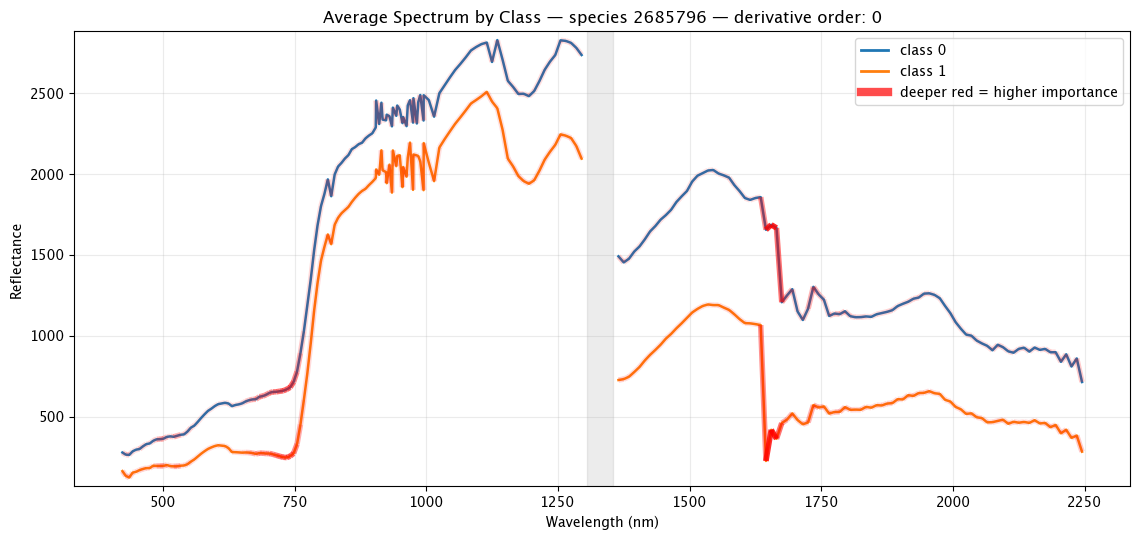

In [98]:
band_df = load_enmap_band_meta_txt("./data/enmap_downloads/enmap_spectral_bands.txt")
print(band_df.head(), len(band_df))

# Now use in your viz:
plot_average_spectrum_with_importance(df, "2685796", band_df)


In [21]:
def plot_avg_spectrum_with_band_importance(
    df: pd.DataFrame,
    species_code: str,
    band_df: pd.DataFrame,
    title_prefix: str = "Average Spectrum + Band Importances",
    derivative_order: int = 0,
    red_alpha_range=(0.02, 0.3),   # toned-down default
    red_gamma=0.7,
):
    """
    Draw average spectra for classes 0/1 and overlay *vertical red bands*
    with opacity proportional to per-band feature importance.
    """
    # ---- Extract X, y ----
    band_cols = [c for c in df.columns if c.startswith("band_")]
    if not band_cols:
        raise ValueError("No band_* columns found in df.")
    X = df[band_cols].to_numpy(dtype=float)

    if species_code not in df.columns:
        raise ValueError(f"Target '{species_code}' not found in df.")
    y = df[species_code].to_numpy(dtype=float)

    keep_rows = ~np.isnan(y)
    X, y = X[keep_rows], y[keep_rows].astype(int)

    n_bands = X.shape[1]

    # ---- Identify bad bands (any -32768 anywhere in that column) ----
    bad_band = np.any(X == -32768, axis=0)
    X[X == -32768] = np.nan

    # ---- Train RF for importances ----
    rf = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1,
    )
    col_med = np.nanmedian(X, axis=0)
    X_train = np.where(np.isnan(X), col_med, X)
    rf.fit(X_train, y)
    importances = rf.feature_importances_

    # ---- Build wavelength centers and edges ----
    def get_series(name_variants):
        for nv in name_variants:
            for col in band_df.columns:
                if str(col).strip().lower() == nv:
                    return band_df[col].to_numpy()
        return None

    start = get_series(["start wl", "startwl", "start_wl"])
    end   = get_series(["end wl", "endwl", "end_wl"])
    mid   = get_series(["middle wl", "middlewl", "cw (nm)", "cw", "center wl", "centerwl"])
    width = get_series(["fwhm (nm)", "fwhm", "sp.rg.", "spectral range", "sp rg", "sp_rg"])

    if start is not None and end is not None:
        centers = 0.5 * (start + end)
        left_edges = start
        right_edges = end
    elif (mid is not None) and (width is not None):
        centers = mid
        left_edges = mid - width / 2.0
        right_edges = mid + width / 2.0
    elif mid is not None:
        centers = mid
        edges = np.zeros(len(centers) + 1, dtype=float)
        edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
        first_gap = centers[1] - centers[0]
        last_gap = centers[-1] - centers[-2]
        edges[0] = centers[0] - first_gap / 2.0
        edges[-1] = centers[-1] + last_gap / 2.0
        left_edges = edges[:-1]
        right_edges = edges[1:]
    else:
        raise ValueError("band_df needs either Start+End WL, or Middle/CW (nm) (±width).")

    centers = centers[:n_bands]
    left_edges = left_edges[:n_bands]
    right_edges = right_edges[:n_bands]

    # ---- Sort by wavelength ----
    order = np.argsort(centers)
    wl = centers[order]
    wl_left = left_edges[order]
    wl_right = right_edges[order]
    imp = importances[order]
    bad_sorted = bad_band[order]

    # ---- Class means ----
    mean0 = np.nanmean(X[y == 0], axis=0)[order]
    mean1 = np.nanmean(X[y == 1], axis=0)[order]

    m0 = np.ma.masked_where(bad_sorted, mean0)
    m1 = np.ma.masked_where(bad_sorted, mean1)

    # ---- Derivative ----
    def masked_derivative(vals_ma, x, n):
        if n <= 0:
            return vals_ma
        out = vals_ma.copy()
        for _ in range(n):
            arr = out.filled(np.nan)
            darr = np.gradient(arr, x)
            out = np.ma.masked_invalid(darr)
            out.mask = np.logical_or(out.mask, vals_ma.mask)
        return out

    m0 = masked_derivative(m0, wl, derivative_order)
    m1 = masked_derivative(m1, wl, derivative_order)

    # ---- Red alpha per band ----
    imp_norm = imp / imp.max() if imp.max() > 0 else np.zeros_like(imp)
    a_min, a_max = red_alpha_range
    alpha_red = a_min + (a_max - a_min) * (imp_norm ** red_gamma)

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(12, 5.6))

    # 1) Red spans (no border)
    for L, R, a in zip(wl_left, wl_right, alpha_red):
        ax.axvspan(L, R, color="red", alpha=a, zorder=0, linewidth=0)

    # 2) Gray mask spans (more visible)
    masked_idx = np.where(bad_sorted)[0]
    if masked_idx.size:
        runs = np.split(masked_idx, np.where(np.diff(masked_idx) != 1)[0] + 1)
        for r in runs:
            L = wl_left[r[0]]
            R = wl_right[r[-1]]
            ax.axvspan(L, R, color="gray", alpha=0.35, zorder=2, linewidth=0)


    # 3) Spectra
    ax.plot(wl, m0, label="class 0", linewidth=1.4, zorder=3)
    ax.plot(wl, m1, label="class 1", linewidth=1.4, zorder=3)

    # Y-limits ignoring masked
    vals = np.concatenate([m0.compressed(), m1.compressed()])
    if vals.size:
        vmin, vmax = np.nanmin(vals), np.nanmax(vals)
        pad = 0.03 * (vmax - vmin if vmax > vmin else 1.0)
        ax.set_ylim(vmin - pad, vmax + pad)

    # Labels
    ylab = "Reflectance" if derivative_order == 0 else f"{derivative_order}ᵗʰ derivative"
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(ylab)
    ax.set_title(f"{title_prefix} — species {species_code} — derivative: {derivative_order}")
    ax.grid(True, alpha=0.25)

    from matplotlib.patches import Patch
    red_patch = Patch(facecolor="red", alpha=0.4, label="band importance (deeper red = higher)")
    ax.legend(handles=[ax.lines[0], ax.lines[1], red_patch], loc="best")

    plt.tight_layout()
    plt.show()


/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1863041176.py:92: RuntimeWarning: Mean of empty slice
  mean0 = np.nanmean(X[y == 0], axis=0)[order]
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1863041176.py:93: RuntimeWarning: Mean of empty slice
  mean1 = np.nanmean(X[y == 1], axis=0)[order]


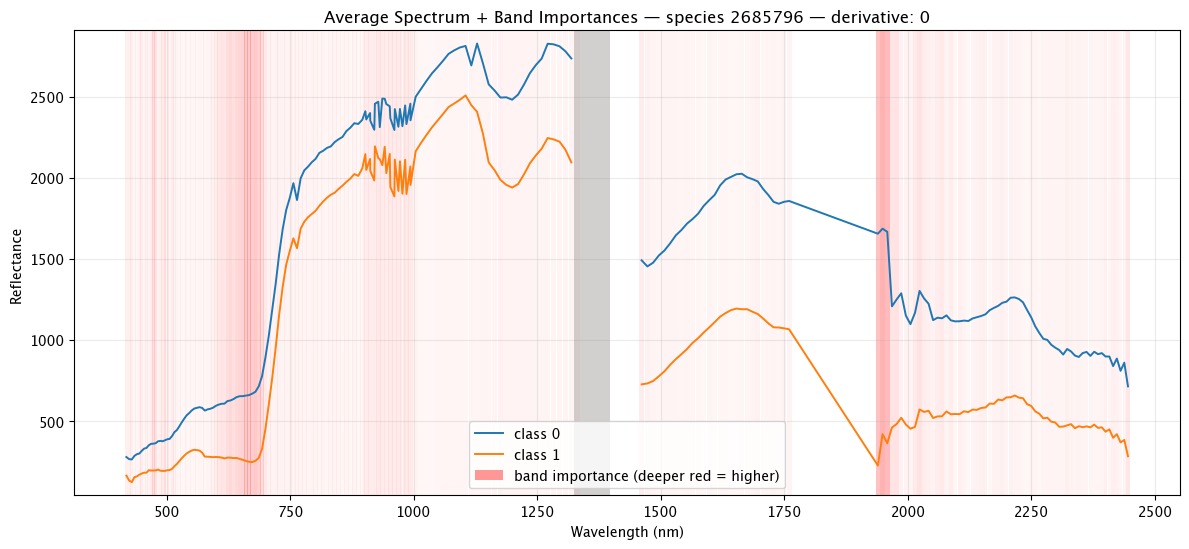

/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1863041176.py:92: RuntimeWarning: Mean of empty slice
  mean0 = np.nanmean(X[y == 0], axis=0)[order]
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1863041176.py:93: RuntimeWarning: Mean of empty slice
  mean1 = np.nanmean(X[y == 1], axis=0)[order]


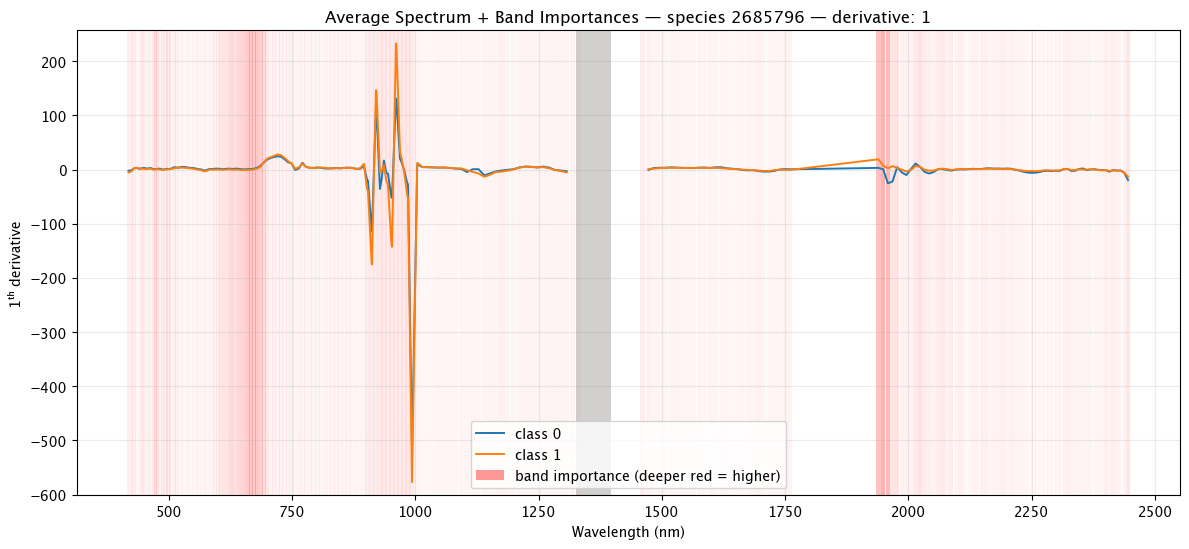

In [22]:
# Using your df and the parsed band_df (with Start/Middle/End WL)
plot_avg_spectrum_with_band_importance(df, "2685796", band_df, derivative_order=0)
# First derivative with the same red band heatmap
plot_avg_spectrum_with_band_importance(df, "2685796", band_df, derivative_order=1)


In [17]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from sklearn.ensemble import RandomForestClassifier

def plot_average_spectrum_with_importance(
    df: pd.DataFrame,
    species_code: str,
    band_df: pd.DataFrame,
    title_prefix: str = "Average Spectrum by Class",
    derivative_order: int = 0,
    nodata_value: float = -32768.0,
    keep_mask: np.ndarray | pd.Series | dict | None = None,  # full-sensor mask (True=keep)
    band_number_col: str = "BAND #",                         # in band_df
    cw_col_options: tuple[str, ...] = ("CW (nm)", "Middle WL"),
    band_prefix: str = "band_",
):
    """
    Plot average spectrum (or its n-th derivative) for classes 0/1 with
    feature importance shown as a red overlay (deeper red = more important).

    - Aligns wavelengths to the actual band_* columns by parsing the band number.
    - Gray-spans any band that (a) appears in keep_mask=False or (b) contains nodata_value in df.
    - If band_df includes more bands than df (e.g., 224/244), 'missing' bands are ignored but counted.

    Parameters
    ----------
    df : DataFrame with band_* columns and binary column `species_code`
    species_code : name of the binary target column (0/1)
    band_df : DataFrame with at least band numbers and CW (nm) (or Middle WL)
    derivative_order : 0, 1, 2, ...
    nodata_value : value considered as NoData in df
    keep_mask : optional mask for the full sensor (len = total sensor bands) or {band_no: bool}
    band_number_col : column in band_df containing 1-based band numbers
    cw_col_options : ordered preference for center wavelength column names
    band_prefix : prefix of spectral columns in df (e.g., "band_")
    """
    # --------------- collect & align band columns -----------------
    band_cols = [c for c in df.columns if c.startswith(band_prefix)]
    if not band_cols:
        raise ValueError(f"No {band_prefix}* columns found in df.")

    # parse band number from "band_###"
    def parse_idx(col: str) -> int:
        m = re.match(rf"{re.escape(band_prefix)}(\d+)$", col)
        if not m:
            raise ValueError(f"Column '{col}' doesn't match '{band_prefix}<int>'")
        return int(m.group(1))

    col_bandno = np.array([parse_idx(c) for c in band_cols])
    order_cols = np.argsort(col_bandno)
    band_cols = [band_cols[i] for i in order_cols]
    band_nos = col_bandno[order_cols]  # 1-based numbers present in df
    n_bands_df = len(band_cols)

    # --------------- wavelengths from band_df --------------------
    if band_number_col not in band_df.columns:
        raise ValueError(f"band_df must have column '{band_number_col}' with band numbers.")

    # choose CW column
    cw_col = None
    for c in cw_col_options:
        if c in band_df.columns:
            cw_col = c
            break
    if cw_col is None:
        # try Start/End WL fallback
        cols_low = {c.lower(): c for c in band_df.columns}
        start_col = next((v for k, v in cols_low.items() if "start" in k and "wl" in k), None)
        end_col   = next((v for k, v in cols_low.items() if "end"   in k and "wl" in k), None)
        if not (start_col and end_col):
            raise ValueError("band_df needs 'CW (nm)' (or 'Middle WL') or Start/End WL.")
        band_df = band_df.copy()
        band_df["__CW__"] = 0.5 * (band_df[start_col].to_numpy() + band_df[end_col].to_numpy())
        cw_col = "__CW__"

    # map band number -> cw
    b2cw = pd.Series(band_df[cw_col].to_numpy(),
                     index=band_df[band_number_col].astype(int)).to_dict()
    # gather cw for the columns we actually have
    missing_in_meta = [b for b in band_nos if b not in b2cw]
    if missing_in_meta:
        raise ValueError(f"band_df missing metadata for bands: {missing_in_meta[:10]} ...")
    wl = np.array([b2cw[b] for b in band_nos])

    # --------------- keep_mask alignment -------------------------
    # Normalize keep_mask to dict {band_no: bool}
    keep_map: dict[int, bool] | None = None
    if keep_mask is not None:
        if isinstance(keep_mask, dict):
            keep_map = {int(k): bool(v) for k, v in keep_mask.items()}
        else:
            arr = np.asarray(keep_mask).ravel()
            # If length equals total sensor bands in band_df, index by band_df[band_number_col]
            if len(arr) == len(band_df):
                nums = band_df[band_number_col].astype(int).to_numpy()
                keep_map = {int(n): bool(arr[i]) for i, n in enumerate(nums)}
            elif len(arr) == n_bands_df:
                # already aligned to df columns
                keep_map = {int(b): bool(arr[i]) for i, b in enumerate(band_nos)}
            else:
                raise ValueError(
                    f"keep_mask length {len(arr)} doesn't match band_df ({len(band_df)}) "
                    f"or df's bands ({n_bands_df})."
                )

    # keep mask for our columns (True=keep, False=drop)
    keep_for_cols = np.ones(n_bands_df, dtype=bool)
    if keep_map is not None:
        keep_for_cols = np.array([keep_map.get(int(b), True) for b in band_nos], dtype=bool)

    # --------------- build X/y, handle nodata --------------------
    if species_code not in df.columns:
        raise ValueError(f"Target column '{species_code}' not found in df.")
    y = df[species_code].to_numpy()
    good_y = ~pd.isna(y)
    y = y[good_y].astype(int)

    X = df.loc[good_y, band_cols].to_numpy(dtype=float)
    # treat nodata_value as NaN
    if np.isfinite(nodata_value):
        X[X == nodata_value] = np.nan

    # bands with any NaN (from nodata) across remaining rows
    bad_from_values = np.any(np.isnan(X), axis=0)

    # final "gray" mask for plotting (True = gray out)
    gray_mask = (~keep_for_cols) | bad_from_values

    # --------------- quick RF importances (median impute) --------
    X_imp = X.copy()
    col_medians = np.nanmedian(X_imp, axis=0)
    # if an entire column is NaN, set median to 0 to avoid all-NaN column
    col_medians = np.where(np.isfinite(col_medians), col_medians, 0.0)
    # fill
    inds = np.where(np.isnan(X_imp))
    X_imp[inds] = np.take(col_medians, inds[1])

    rf = RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1,
    )
    rf.fit(X_imp, y)
    importances = rf.feature_importances_

    # --------------- class means (masked by gray) ----------------
    def class_mean(label):
        arr = X[y == label]
        if arr.size == 0:
            return np.full(n_bands_df, np.nan)
        return np.nanmean(arr, axis=0)

    mean0 = class_mean(0)
    mean1 = class_mean(1)

    m0 = np.ma.masked_where(gray_mask, mean0)
    m1 = np.ma.masked_where(gray_mask, mean1)

    # --------------- optional derivatives ------------------------
    def masked_derivative(vals_ma: np.ma.MaskedArray, x: np.ndarray, n: int) -> np.ma.MaskedArray:
        if n <= 0:
            return vals_ma
        out = vals_ma.copy()
        for _ in range(n):
            arr = out.filled(np.nan)
            darr = np.gradient(arr, x)
            out = np.ma.masked_invalid(darr)
            out.mask = np.logical_or(out.mask, vals_ma.mask)
        return out

    m0 = masked_derivative(m0, wl, derivative_order)
    m1 = masked_derivative(m1, wl, derivative_order)

    # --------------- importance -> red alpha ---------------------
    imp = importances
    imp_norm = imp / imp.max() if imp.max() > 0 else np.zeros_like(imp)
    gamma = 0.7
    red_alpha = 0.05 + 0.85 * (imp_norm ** gamma)

    def red_overlay(ax, x, y_ma, alpha_per_band):
        valid = ~y_ma.mask
        idx = np.where(valid)[0]
        if idx.size < 2:
            return
        splits = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
        for run in splits:
            if len(run) < 2:
                continue
            seg_x = x[run]
            seg_y = y_ma[run].filled(np.nan)
            seg_a = alpha_per_band[run]
            pts = np.column_stack([seg_x, seg_y])
            segments = np.stack([pts[:-1], pts[1:]], axis=1)
            seg_alpha = 0.5 * (seg_a[:-1] + seg_a[1:])
            colors = np.zeros((len(segments), 4))
            colors[:, 0] = 1.0
            colors[:, 3] = seg_alpha
            ax.add_collection(LineCollection(segments, colors=colors, linewidths=4, zorder=4))

    # --------------- plot ----------------------------------------
    fig, ax = plt.subplots(figsize=(11.5, 5.5))

    # gray spans for contiguous gray_mask runs
    gray_idx = np.where(gray_mask)[0]
    if gray_idx.size:
        runs = np.split(gray_idx, np.where(np.diff(gray_idx) != 1)[0] + 1)
        for r in runs:
            ax.axvspan(wl[r[0]], wl[r[-1]], color="gray", alpha=0.15, zorder=0)

    lbl0, lbl1 = "class 0", "class 1"
    line0, = ax.plot(wl, m0, label=lbl0, linewidth=1.8, zorder=2)
    line1, = ax.plot(wl, m1, label=lbl1, linewidth=1.8, zorder=3)

    red_overlay(ax, wl, m0, red_alpha)
    red_overlay(ax, wl, m1, red_alpha)

    vals = np.concatenate([m0.compressed(), m1.compressed()]) if m0.count()+m1.count() else np.array([])
    if vals.size:
        vmin, vmax = np.nanmin(vals), np.nanmax(vals)
        pad = 0.02 * (vmax - vmin if vmax > vmin else 1.0)
        ax.set_ylim(vmin - pad, vmax + pad)

    kept_ct   = int((~gray_mask).sum())
    dropped_ct= int(gray_mask.sum())

    ylab = "Reflectance" if derivative_order == 0 else f"{derivative_order}ᵗʰ derivative"
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(ylab)
    ax.set_title(f"{title_prefix} — species {species_code} — kept {kept_ct}, dropped {dropped_ct}")

    proxy_red = Line2D([0],[0], color="red", lw=6, alpha=0.7)
    ax.legend(handles=[
        Line2D([0],[0], color=line0.get_color(), lw=2, label=lbl0),
        Line2D([0],[0], color=line1.get_color(), lw=2, label=lbl1),
        proxy_red
    ], labels=[lbl0, lbl1, "deeper red = higher importance"], loc="best")

    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


In [18]:
# --- 0) Imports (plus your plotting function must already be defined/imported) ---
import pandas as pd



In [19]:
import pandas as pd
import xml.etree.ElementTree as ET

xml_path = "./data/enmap_downloads/enmap_band_characterisation.xml"  # path to your XML file

# Parse XML
tree = ET.parse(xml_path)
root = tree.getroot()

records = []
for band in root.findall(".//bandID"):
    number = int(band.attrib["number"])
    cw = float(band.find("wavelengthCenterOfBand").text)
    fwhm = float(band.find("FWHMOfBand").text)
    gain = float(band.find("GainOfBand").text)
    offset = float(band.find("OffsetOfBand").text)
    records.append((number, cw, fwhm, gain, offset))

# Create DataFrame
band_df = pd.DataFrame(
    records,
    columns=["BAND #", "CW (nm)", "FWHM (nm)", "Gain", "Offset"]
)

# Sort just in case
band_df = band_df.sort_values("BAND #").reset_index(drop=True)

print(band_df.head())
print(len(band_df), "bands loaded")


   BAND #  CW (nm)  FWHM (nm)    Gain  Offset
0       1  418.416    6.99561  0.0001     0.0
1       2  424.043    6.66750  0.0001     0.0
2       3  429.457    6.42408  0.0001     0.0
3       4  434.686    6.25124  0.0001     0.0
4       5  439.758    6.13485  0.0001     0.0
224 bands loaded


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

def plot_avg_spectrum_with_band_importance(
    df: pd.DataFrame,
    species_code: str,
    band_df: pd.DataFrame,
    title_prefix: str = "Average Spectrum + Band Importances",
    derivative_order: int = 0,
    red_alpha_range=(0.02, 0.30),
    red_gamma: float = 0.7,
    respect_masks: bool = True,
    gap_alpha: float = 0.18,                # blue shading transparency
    gap_color: str = "#76a5ff",             # blue shading color
    drop_alpha: float = 0.35,               # dropped-band shading (gray)
    keep_ranges_nm=None,                    # usable ranges; default = EnMAP windows
):
    """
    Average spectra for classes 0/1 with vertical red bands (per-band
    importances). We *only* draw spectra inside `keep_ranges_nm` and
    shade everything outside those windows in light blue.
    """

    if keep_ranges_nm is None:
        # Typical EnMAP L2A usable ranges
        keep_ranges_nm = [(430, 1340), (1450, 1780), (1980, 2450)]

    # ---- X, y ----
    band_cols = [c for c in df.columns if c.startswith("band_")]
    if not band_cols:
        raise ValueError("No band_* columns found in df.")
    X = df[band_cols].to_numpy(dtype=float)

    if species_code not in df.columns:
        raise ValueError(f"Target '{species_code}' not found in df.")
    y = df[species_code].to_numpy(dtype=float)

    keep_rows = ~np.isnan(y)
    X, y = X[keep_rows], y[keep_rows].astype(int)
    n_bands = X.shape[1]

    # ---- Dropped bands via sentinel ----
    bad_band = np.any(X == -32768, axis=0)
    X[X == -32768] = np.nan

    # ---- Importances (median-impute) ----
    rf = RandomForestClassifier(
        n_estimators=400, random_state=42, class_weight="balanced_subsample", n_jobs=-1
    )
    col_med = np.nanmedian(X, axis=0)
    X_train = np.where(np.isnan(X), col_med, X)
    rf.fit(X_train, y)
    importances = rf.feature_importances_

    # ---- Wavelength centers & edges from band_df ----
    def get_series(name_variants):
        for nv in name_variants:
            for col in band_df.columns:
                if str(col).strip().lower() == nv:
                    return band_df[col].to_numpy()
        return None

    start = get_series(["start wl", "startwl", "start_wl"])
    end   = get_series(["end wl", "endwl", "end_wl"])
    mid   = get_series(["middle wl", "middlewl", "cw (nm)", "cw", "center wl", "centerwl"])
    width = get_series(["fwhm (nm)", "fwhm", "sp.rg.", "spectral range", "sp rg", "sp_rg"])

    if start is not None and end is not None:
        centers = 0.5 * (start + end)
        left_edges = start
        right_edges = end
    elif (mid is not None) and (width is not None):
        centers = mid
        left_edges = mid - width / 2.0
        right_edges = mid + width / 2.0
    elif mid is not None:
        centers = mid
        edges = np.zeros(len(centers) + 1, dtype=float)
        edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
        first_gap = centers[1] - centers[0]
        last_gap = centers[-1] - centers[-2]
        edges[0] = centers[0] - first_gap / 2.0
        edges[-1] = centers[-1] + last_gap / 2.0
        left_edges = edges[:-1]
        right_edges = edges[1:]
    else:
        raise ValueError("band_df needs either Start+End WL, or Middle/CW (nm) (±width).")

    centers    = centers[:n_bands]
    left_edges = left_edges[:n_bands]
    right_edges= right_edges[:n_bands]

    # ---- Sort by wavelength ----
    order = np.argsort(centers)
    wl       = centers[order]
    wl_left  = left_edges[order]
    wl_right = right_edges[order]
    imp      = importances[order]
    bad_sorted = bad_band[order]

    # ---- Build 'in_keep' mask from keep_ranges_nm ----
    in_keep = np.zeros_like(wl, dtype=bool)
    for a, b in keep_ranges_nm:
        in_keep |= (wl >= a) & (wl <= b)

    # ---- Class means ----
    mean0 = np.nanmean(X[y == 0], axis=0)[order]
    mean1 = np.nanmean(X[y == 1], axis=0)[order]

    # also treat non-finite means as invalid
    invalid0 = bad_sorted | (~in_keep) | (~np.isfinite(mean0))
    invalid1 = bad_sorted | (~in_keep) | (~np.isfinite(mean1))

    m0 = np.ma.array(mean0, mask=invalid0)
    m1 = np.ma.array(mean1, mask=invalid1)

    # ---- Optional derivative ----
    def masked_derivative(vals_ma, x, n):
        if n <= 0:
            return vals_ma
        out = vals_ma.copy()
        for _ in range(n):
            arr = out.filled(np.nan)
            darr = np.gradient(arr, x)
            out = np.ma.masked_invalid(darr)
            out.mask = np.logical_or(out.mask, vals_ma.mask)
        return out

    m0 = masked_derivative(m0, wl, derivative_order)
    m1 = masked_derivative(m1, wl, derivative_order)

    # ---- Red alpha per band (zero outside keep or masked) ----
    imp_norm = imp / imp.max() if imp.max() > 0 else np.zeros_like(imp)
    a_min, a_max = red_alpha_range
    alpha_red = a_min + (a_max - a_min) * (imp_norm ** red_gamma)
    blocked = (~in_keep) | bad_sorted
    if respect_masks:
        alpha_red = np.where(blocked, 0.0, alpha_red)

    # ---- Helper to make spans from a boolean mask over bands ----
    def spans_from_bool(left, right, flag_true):
        spans = []
        i, n = 0, len(flag_true)
        while i < n:
            if flag_true[i]:
                j = i
                while j + 1 < n and flag_true[j + 1]:
                    j += 1
                spans.append((left[i], right[j]))
                i = j + 1
            else:
                i += 1
        return spans

    # Spans to shade: everything OUTSIDE the keep ranges
    outside_spans = spans_from_bool(wl_left, wl_right, ~in_keep)

    # --------------- Plot ----------------
    fig, ax = plt.subplots(figsize=(12, 5.6))

    # 0) Shade outside-keep regions in light blue
    for L, R in outside_spans:
        ax.axvspan(L, R, color=gap_color, alpha=gap_alpha, zorder=0, linewidth=0)

    # 1) Red importance spans (only inside keep + not dropped)
    for L, R, a, ok in zip(wl_left, wl_right, alpha_red, ~blocked):
        if ok and a > 0:
            ax.axvspan(L, R, color="red", alpha=a, zorder=1, linewidth=0)

    # 2) Dropped/masked bands (gray)
    masked_idx = np.where(bad_sorted & in_keep)[0]
    if masked_idx.size:
        runs = np.split(masked_idx, np.where(np.diff(masked_idx) != 1)[0] + 1)
        for r in runs:
            L = wl_left[r[0]]
            R = wl_right[r[-1]]
            ax.axvspan(L, R, color="gray", alpha=drop_alpha, zorder=2, linewidth=0)

    # Pick consistent colors for all segments
    color0 = "C0"  # default matplotlib first color (blue)
    color1 = "C1"  # default matplotlib second color (orange)

    # 3) Plot spectra in contiguous segments strictly within keep ranges
    def plot_segmented(ax, x, y_ma, label=None, color=None, **kw):
        mask = np.asarray(y_ma.mask, dtype=bool)
        start = None
        first_line = None
        for i in range(len(x)):
            if mask[i]:
                if start is not None:
                    ln, = ax.plot(x[start:i], y_ma.data[start:i], color=color, **kw)
                    if first_line is None and label is not None:
                        ln.set_label(label)
                        first_line = ln
                    start = None
            else:
                if start is None:
                    start = i
        if start is not None:
            ln, = ax.plot(x[start:], y_ma.data[start:], color=color, **kw)
            if first_line is None and label is not None:
                ln.set_label(label)
                first_line = ln
        return first_line

    # Call with fixed colors
    line0 = plot_segmented(ax, wl, m0, label="class 0", color=color0, linewidth=1.4, zorder=3)
    line1 = plot_segmented(ax, wl, m1, label="class 1", color=color1, linewidth=1.4, zorder=3)


    # Y-lims ignoring masked
    vals = np.concatenate([m0.compressed(), m1.compressed()])
    if vals.size:
        vmin, vmax = np.nanmin(vals), np.nanmax(vals)
        pad = 0.03 * (vmax - vmin if vmax > vmin else 1.0)
        ax.set_ylim(vmin - pad, vmax + pad)

    # Labels / legend
    ylab = "Reflectance" if derivative_order == 0 else f"{derivative_order}ᵗʰ derivative"
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(ylab)
    ax.set_title(f"{title_prefix} — species {species_code} — derivative: {derivative_order}")
    ax.grid(True, alpha=0.25)

    from matplotlib.patches import Patch
    red_patch  = Patch(facecolor="red",  alpha=0.4, label="band importance (deeper red = higher)")
    gap_patch  = Patch(facecolor=gap_color, alpha=gap_alpha, label="instrument band gaps")
    drop_patch = Patch(facecolor="gray", alpha=drop_alpha, label="dropped bands")
    ax.legend(handles=[line0, line1, red_patch, gap_patch, drop_patch], loc="best")

    plt.tight_layout()
    plt.show()


/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1049981048.py:52: RuntimeWarning: All-NaN slice encountered
  col_med = np.nanmedian(X, axis=0)
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1049981048.py:109: RuntimeWarning: Mean of empty slice
  mean0 = np.nanmean(X[y == 0], axis=0)[order]
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1049981048.py:110: RuntimeWarning: Mean of empty slice
  mean1 = np.nanmean(X[y == 1], axis=0)[order]


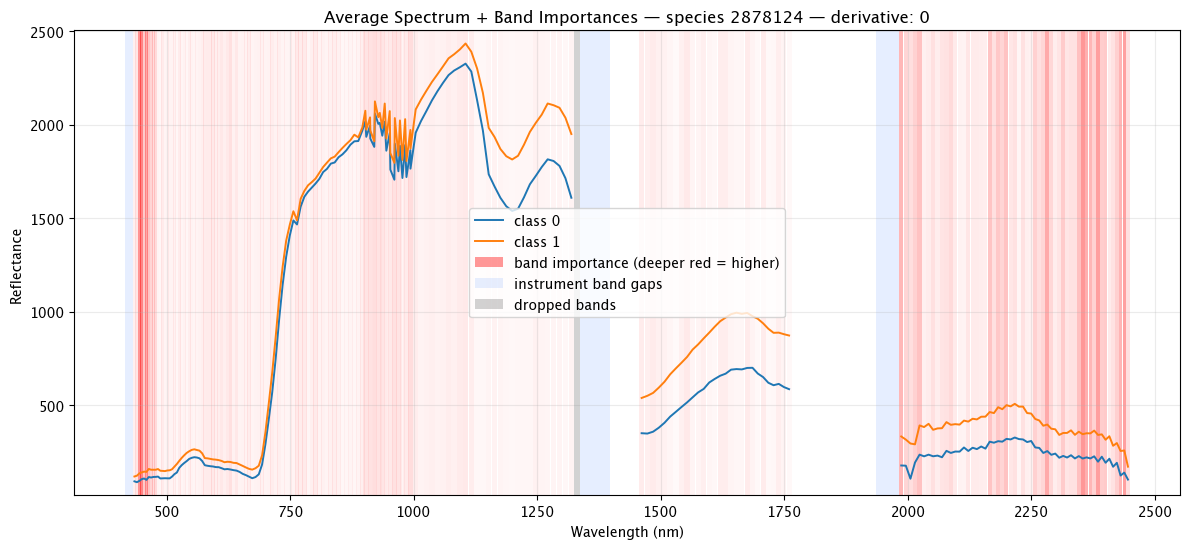

In [52]:
# Typical EnMAP L2A usable ranges
enmap_keep = [(430, 1340), (1450, 1780), (1980, 2450)]

plot_avg_spectrum_with_band_importance(
    df,
    species_code="2878124",
    band_df=band_df,                 # parsed from your XML or CSV
    derivative_order=0,
    # keep_ranges_nm=enmap_keep,       # optional (defaults to these)
    # min_valid_frac=0.7,              # ignore bands with too many NaNs
    # autoscale_reflectance=True,      # divide by 10000 if needed
    red_alpha_range=(0.02, 0.5),    # tone down red
)


/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/297742684.py:47: RuntimeWarning: All-NaN slice encountered
  col_med = np.nanmedian(X, axis=0)
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/297742684.py:108: RuntimeWarning: Mean of empty slice
  mean0 = np.nanmean(X[y == 0], axis=0)[order]
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/297742684.py:109: RuntimeWarning: Mean of empty slice
  mean1 = np.nanmean(X[y == 1], axis=0)[order]


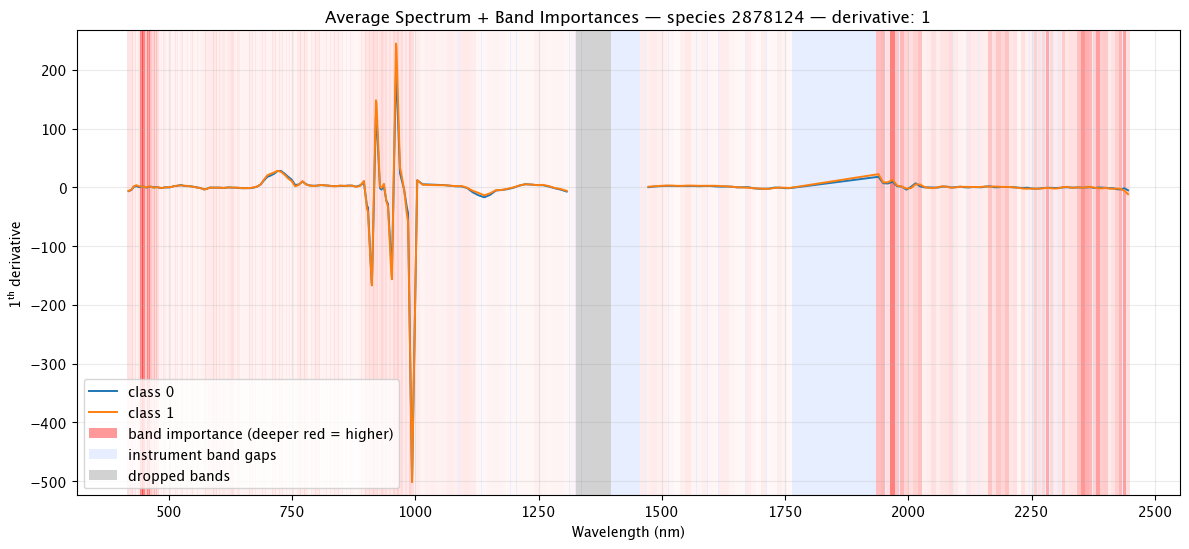

In [40]:
plot_avg_spectrum_with_band_importance(
    df,
    species_code="2878124",
    band_df=band_df,                 # parsed from your XML or CSV
    derivative_order=1,
    # keep_ranges_nm=enmap_keep,       # optional (defaults to these)
    # min_valid_frac=0.7,              # ignore bands with too many NaNs
    # autoscale_reflectance=True,      # divide by 10000 if needed
    red_alpha_range=(0.02, 0.5),    # tone down red
)


Found 224 band columns in df.


/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1863041176.py:40: RuntimeWarning: All-NaN slice encountered
  col_med = np.nanmedian(X, axis=0)
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1863041176.py:92: RuntimeWarning: Mean of empty slice
  mean0 = np.nanmean(X[y == 0], axis=0)[order]
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1863041176.py:93: RuntimeWarning: Mean of empty slice
  mean1 = np.nanmean(X[y == 1], axis=0)[order]


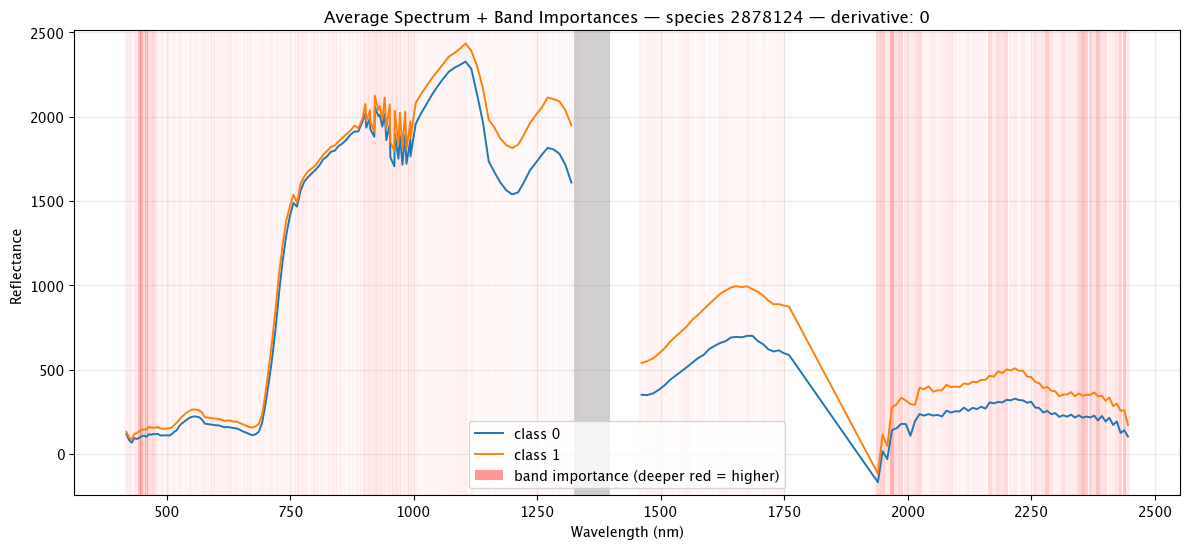

/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1863041176.py:40: RuntimeWarning: All-NaN slice encountered
  col_med = np.nanmedian(X, axis=0)
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1863041176.py:92: RuntimeWarning: Mean of empty slice
  mean0 = np.nanmean(X[y == 0], axis=0)[order]
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/1863041176.py:93: RuntimeWarning: Mean of empty slice
  mean1 = np.nanmean(X[y == 1], axis=0)[order]


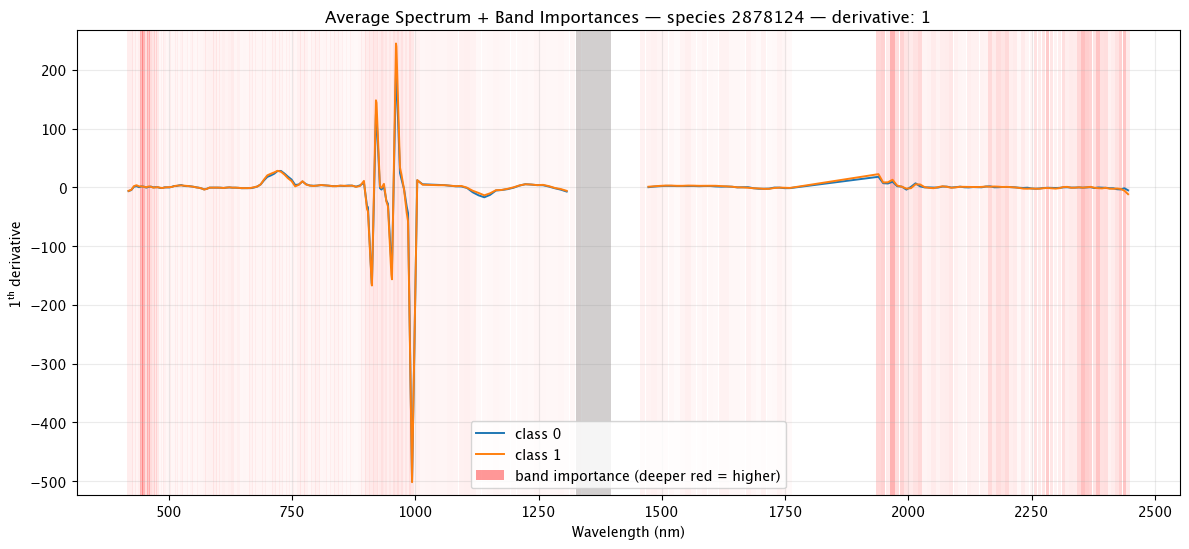

In [23]:

# --- 2) Pick the target species column ---
species_code = "2878124"   # example: your GBIF/ID column present in df (0/1)

# --- 3) (Optional) sanity checks ---
# Ensure band counts match (not required, but helpful)
band_cols = [c for c in df.columns if c.startswith("band_")]
print(f"Found {len(band_cols)} band columns in df.")

# --- 4) Call the plotter (raw reflectance) ---
plot_avg_spectrum_with_band_importance(
    df=df,
    species_code=species_code,
    band_df=band_df,
    title_prefix="Average Spectrum + Band Importances",
    derivative_order=0,              # 0=raw, 1=first derivative, 2=second, ...
    red_alpha_range=(0.02, 0.30),    # how strong the red importance overlay is
    red_gamma=0.7,                   # contrast curve for importance
)

# --- 5) (Optional) first-derivative view ---
plot_avg_spectrum_with_band_importance(
    df=df,
    species_code=species_code,
    band_df=band_df,
    title_prefix="Average Spectrum + Band Importances",
    derivative_order=1,
    red_alpha_range=(0.02, 0.30),
    red_gamma=0.7,
)


/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/346355696.py:135: RuntimeWarning: All-NaN slice encountered
  col_medians = np.nanmedian(X_imp, axis=0)
/var/folders/qx/bpj16cl90cq20swjd4j79cdh0000gn/T/ipykernel_5532/346355696.py:156: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr, axis=0)


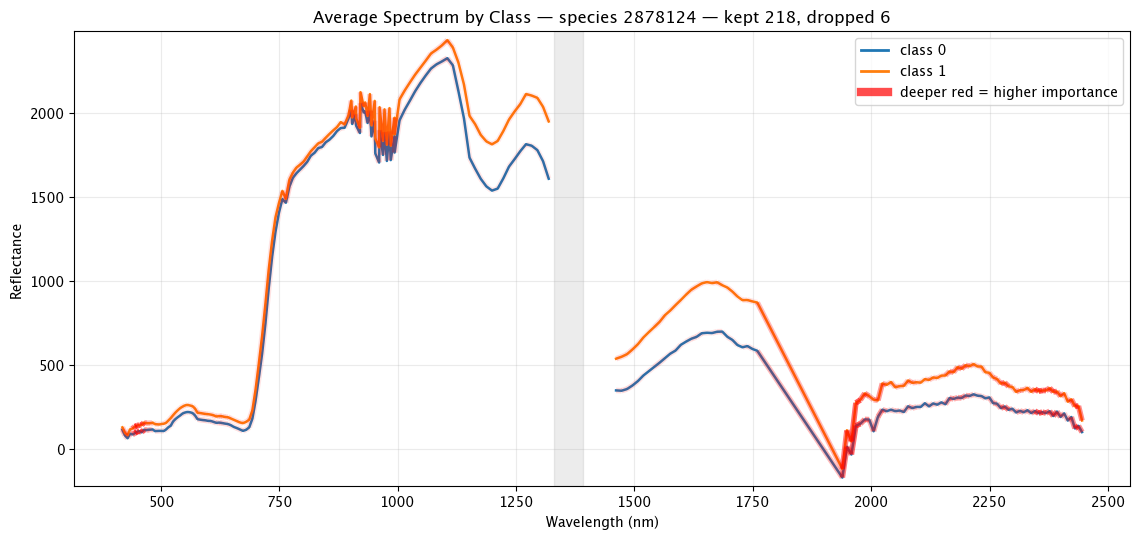

In [13]:
# --- Example setup ---
import pandas as pd

# 1. Load your spectral dataset (features + target)
# df should have:
#   - columns: band_1, band_2, ..., band_N
#   - a binary column for the target species (1=present, 0=absent)
df = pd.read_parquet(training_dataset_path)  # Example path

# 2. Load EnMAP band metadata table
# band_df must contain wavelength info in one of:
#   - "CW (nm)" (center wavelength in nm)
#   - "Middle WL"
#   - or Start/End WL
# band_df = pd.read_csv("enmap_band_characterisation.csv")  # From XML parse or provided CSV

# 3. Pick a species code column from your dataset
species_code = "2878124"  # Example GBIF taxon ID column

# 4. Call the function
plot_average_spectrum_with_importance(
    df=df,
    species_code=species_code,
    band_df=band_df,
    title_prefix="Average Spectrum by Class",
    derivative_order=0,  # 0 = raw reflectance, 1 = first derivative, etc.
)
